### import and path

In [9]:
import socket
import sys
import pickle
import os
import time
from pprint import pprint

sys.path.append('/home/lxh/dev/DRL-urban-planning')
home_dir= '/home/lxh/dev/DRL-urban-planning/'
root_dir = '/home/lxh/dev/DRL-urban-planning/output_urban_planning/'

### demo

In [10]:
from urban_planning.envs import CityEnv
from urban_planning.envs import city_config
from urban_planning.utils.config import Config

In [11]:
id = 'g6'
seed = 111
temp = False
cfg = Config(id, seed, temp, root_dir)
env = CityEnv(cfg)

Carbon emissions:
{4: 248, 8: 345.9, 5: 193, 6: 906, 7: 0, 9: 321, 10: 20, 11: 18, 12: 20}


In [12]:
init_plan_path = os.path.join(home_dir, 'urban_planning/cfg/test_data/synthetic/init_plan_g6.pickle')
d= pickle.load(open(init_plan_path, 'rb'))
#d['gdf'].to_file('init_grid2.geojson', driver='GeoJSON')

In [13]:
print(d['gdf'])

      id  type  existence                                           geometry
0      1    13       True                            POINT (0.00000 0.00000)
1      2    13       True                          POINT (0.00000 500.00000)
2      3    13       True                         POINT (0.00000 1000.00000)
3      4    13       True                         POINT (0.00000 1500.00000)
4      5    13       True                         POINT (0.00000 2000.00000)
..   ...   ...        ...                                                ...
164  165     1       True  POLYGON ((2500.00000 500.00000, 3000.00000 500...
165  166     1       True  POLYGON ((2500.00000 1000.00000, 3000.00000 10...
166  167     1       True  POLYGON ((2500.00000 1500.00000, 3000.00000 15...
167  168     1       True  POLYGON ((2500.00000 2000.00000, 3000.00000 20...
168  169     1       True  POLYGON ((2500.00000 2500.00000, 3000.00000 25...

[169 rows x 4 columns]


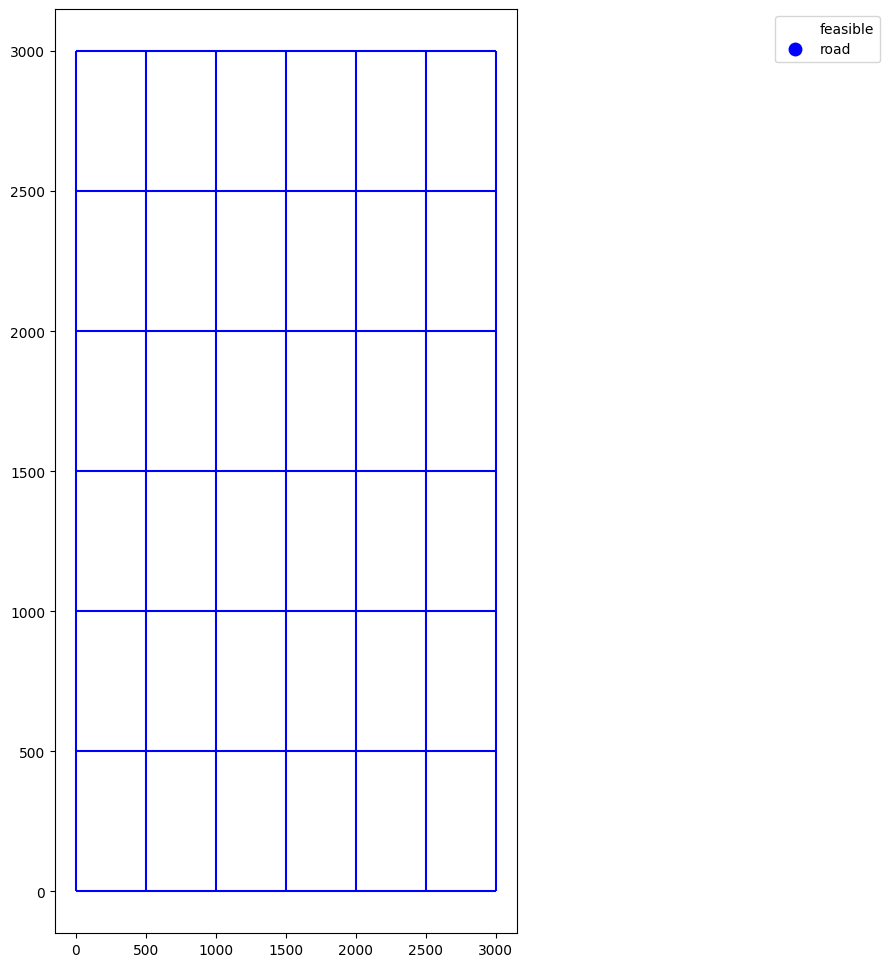

In [14]:
env.load_plan(d['gdf'])
env.visualize()

### load plan and score

In [15]:
env.load_plan(gdf)
env.score_plan()

NameError: name 'gdf' is not defined

In [ ]:
import geojson

def create_grid_geojson(size=3000, divisions=6):
    features = []
    id_counter = 1
    cell_size = size / divisions
    
    # 1. Generate Points
    points = {}  # Dictionary to store points with their coordinates as keys
    for i in range(divisions + 1):
        for j in range(divisions + 1):
            x = i * cell_size
            y = j * cell_size
            coord = (x, y)
            points[coord] = id_counter
            
            point = geojson.Point([x, y])
            feature = geojson.Feature(
                geometry=point,
                properties={
                    "id": id_counter,
                    "type": 13,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

    # 2. Generate Lines
    lines_set = set()  # Set to track unique lines
    for i in range(divisions + 1):
        for j in range(divisions + 1):
            x = i * cell_size
            y = j * cell_size
            
            # Horizontal lines
            if i < divisions:
                line = ((x, y), (x + cell_size, y))
                if line not in lines_set:
                    lines_set.add(line)
                    linestring = geojson.LineString([list(line[0]), list(line[1])])
                    feature = geojson.Feature(
                        geometry=linestring,
                        properties={
                            "id": id_counter,
                            "type": 2,
                            "existence": True
                        }
                    )
                    features.append(feature)
                    id_counter += 1
            
            # Vertical lines
            if j < divisions:
                line = ((x, y), (x, y + cell_size))
                if line not in lines_set:
                    lines_set.add(line)
                    linestring = geojson.LineString([list(line[0]), list(line[1])])
                    feature = geojson.Feature(
                        geometry=linestring,
                        properties={
                            "id": id_counter,
                            "type": 2,
                            "existence": True
                        }
                    )
                    features.append(feature)
                    id_counter += 1

    # 3. Generate Polygons
    for i in range(divisions):
        for j in range(divisions):
            x = i * cell_size
            y = j * cell_size
            polygon_coords = [
                [x, y],
                [x + cell_size, y],
                [x + cell_size, y + cell_size],
                [x, y + cell_size],
                [x, y]
            ]
            polygon = geojson.Polygon([polygon_coords])
            feature = geojson.Feature(
                geometry=polygon,
                properties={
                    "id": id_counter,
                    "type": 1,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

    # Create FeatureCollection
    feature_collection = geojson.FeatureCollection(features)
    
    # Save to file
    with open('grid_6x6.geojson', 'w') as f:
        geojson.dump(feature_collection, f)

# Create the grid
create_grid_geojson(3000, 6)

In [ ]:
import geojson

features = []

# 区域尺寸
length = 2000  # 米
width = 2000   # 米
grid_size = 1000  # 米

id_counter = 1

# 生成小正方形的顶点和边
for x in range(0, length, grid_size):
    for y in range(0, width, grid_size):
        # 定义四个顶点坐标
        v1 = [x, y]
        v2 = [x + grid_size, y]
        v3 = [x + grid_size, y + grid_size]
        v4 = [x, y + grid_size]

        # 创建顶点要素，类型为 13
        for vx, vy in [v1, v2, v3, v4]:
            point = geojson.Point([vx, vy])
            feature = geojson.Feature(
                geometry=point,
                properties={
                    "id": id_counter,
                    "type": 13,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

        # 创建边要素，类型为 2
        edges = [
            [v1, v2],
            [v2, v3],
            [v3, v4],
            [v4, v1]
        ]
        for edge in edges:
            line = geojson.LineString(edge)
            feature = geojson.Feature(
                geometry=line,
                properties={
                    "id": id_counter,
                    "type": 2,
                    "existence": True
                }
            )
            features.append(feature)
            id_counter += 1

        # 可选：创建小正方形的多边形要素（如果需要）
        polygon = geojson.Polygon([[v1, v2, v3, v4, v1]])
        feature = geojson.Feature(
            geometry=polygon,
            properties={
                "id": id_counter,
                "type": 1,  # 多边形类型，可根据需要调整
                "existence": True
            }
        )
        features.append(feature)
        id_counter += 1

# 创建 FeatureCollection
feature_collection = geojson.FeatureCollection(features)

# 保存为 geojson 文件
with open('output.geojson', 'w') as f:
    geojson.dump(feature_collection, f)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 加载 GeoJSON 文件
gdf = gpd.read_file('grid_6x6.geojson')

# 查看前几行数据
print(gdf.head())

# 查看数据的概述
print(gdf.info())



   id  type  existence                    geometry
0   1    13       True     POINT (0.00000 0.00000)
1   2    13       True   POINT (0.00000 500.00000)
2   3    13       True  POINT (0.00000 1000.00000)
3   4    13       True  POINT (0.00000 1500.00000)
4   5    13       True  POINT (0.00000 2000.00000)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         169 non-null    int64   
 1   type       169 non-null    int64   
 2   existence  169 non-null    bool    
 3   geometry   169 non-null    geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 4.3 KB
None


In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         169 non-null    int64   
 1   type       169 non-null    int64   
 2   existence  169 non-null    bool    
 3   geometry   169 non-null    geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 4.3 KB


In [ ]:
import pickle
d={'gdf': gdf}
with open('./init_plan_grid3.pickle', 'wb') as f:
    pickle.dump(d, f)

In [ ]:
d= pickle.load(open('init_plan_grid3.pickle', 'rb'))
print(d)

{'gdf':     id  type  existence                                           geometry
0    1    13       True                                POINT (0.000 0.000)
1    2    13       True                             POINT (1000.000 0.000)
2    3    13       True                          POINT (1000.000 1000.000)
3    4    13       True                             POINT (0.000 1000.000)
4    9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...
5   12    13       True                          POINT (1000.000 2000.000)
6   13    13       True                             POINT (0.000 2000.000)
7   18     1       True  POLYGON ((0.000 1000.000, 1000.000 1000.000, 1...
8   20    13       True                             POINT (2000.000 0.000)
9   21    13       True                          POINT (2000.000 1000.000)
10  27     1       True  POLYGON ((1000.000 0.000, 2000.000 0.000, 2000...
11  30    13       True                          POINT (2000.000 2000.000)
12  36     1     

In [ ]:
gdf=gdf.drop_duplicates(subset='geometry')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         169 non-null    int64   
 1   type       169 non-null    int64   
 2   existence  169 non-null    bool    
 3   geometry   169 non-null    geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 5.4 KB


In [ ]:
from shapely.geometry import Point, LineString

# 生成包含指定记录和LineString的数组
records = [
    {
        'distance': 200,
        'geometry': Point(1500, 1500),
        'land_use': [6, 9, 10],
        'type': 'center'
    },
    {
        'distance': 50,
        'geometry': LineString([(500.0, 1500.0), (1500.0, 2500.0)]),
        'land_use': [5,7,11],
        'type': 'axis'
    },
    {
        'distance': 50,
        'geometry': LineString([(1500.0, 500.0), (1500.0, 2500.0)]),
        'land_use': [5, 9, 11],
        'type': 'axis'
    }
]
concept_dict = {'concept': records, 'gdf': gdf}
print(concept_dict)


{'concept': [{'distance': 200, 'geometry': <shapely.geometry.point.Point object at 0x7f6b0418feb0>, 'land_use': [6, 9, 10], 'type': 'center'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7f6b04736790>, 'land_use': [5, 7, 11], 'type': 'axis'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7f6b04736430>, 'land_use': [5, 9, 11], 'type': 'axis'}], 'gdf':       id  type  existence                                           geometry
0      1    13       True                            POINT (0.00000 0.00000)
1      2    13       True                          POINT (0.00000 500.00000)
2      3    13       True                         POINT (0.00000 1000.00000)
3      4    13       True                         POINT (0.00000 1500.00000)
4      5    13       True                         POINT (0.00000 2000.00000)
..   ...   ...        ...                                                ...
164  165     1       True  POLYGON (

In [ ]:
print(records)

[{'distance': 200, 'geometry': <shapely.geometry.point.Point object at 0x7f6b0418feb0>, 'land_use': [6, 9, 10], 'type': 'center'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7f6b04736790>, 'land_use': [5, 7, 11], 'type': 'axis'}, {'distance': 50, 'geometry': <shapely.geometry.linestring.LineString object at 0x7f6b04736430>, 'land_use': [5, 9, 11], 'type': 'axis'}]


In [ ]:
with open('./init_plan_g6.pickle', 'wb') as f:
    pickle.dump(concept_dict, f)

In [ ]:
gdf[gdf['type']==13]

,id,type,existence,geometry
0,1,13,True,POINT (0.00000 0.00000)
1,2,13,True,POINT (1000.00000 0.00000)
2,3,13,True,POINT (1000.00000 1000.00000)
3,4,13,True,POINT (0.00000 1000.00000)
11,12,13,True,POINT (1000.00000 2000.00000)
12,13,13,True,POINT (0.00000 2000.00000)
19,20,13,True,POINT (2000.00000 0.00000)
20,21,13,True,POINT (2000.00000 1000.00000)
29,30,13,True,POINT (2000.00000 2000.00000)


In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         25 non-null     int64   
 1   type       25 non-null     int64   
 2   existence  25 non-null     bool    
 3   geometry   25 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 753.0 bytes


In [ ]:
import geopandas as gpd
from shapely.geometry import LineString
# 定义一个函数来规范化LineString
def normalize_linestring(ls):
    print(ls)
    coords = list(ls.coords)
    if len(coords) < 2:
        raise ValueError("LineStrings must have at least 2 coordinate tuples")
    return LineString(coords) if coords[0] < coords[-1] else LineString(coords[::-1])

# 应用规范化函数
gdf_line=gdf[gdf['type']==2]
gdf_line['normalized_geometry'] = gdf_line['geometry'].apply(normalize_linestring)

# 删除重复的LineString
gdf_line = gdf_line.drop_duplicates(subset='normalized_geometry')

# 删除辅助列
gdf_line = gdf_line.drop(columns='normalized_geometry')

print(gdf_line)

LINESTRING (0 0, 1000 0)
LINESTRING (1000 0, 1000 1000)
LINESTRING (1000 1000, 0 1000)
LINESTRING (0 1000, 0 0)
LINESTRING (0 1000, 1000 1000)
LINESTRING (1000 1000, 1000 2000)
LINESTRING (1000 2000, 0 2000)
LINESTRING (0 2000, 0 1000)
LINESTRING (1000 0, 2000 0)
LINESTRING (2000 0, 2000 1000)
LINESTRING (2000 1000, 1000 1000)
LINESTRING (1000 1000, 1000 0)
LINESTRING (1000 1000, 2000 1000)
LINESTRING (2000 1000, 2000 2000)
LINESTRING (2000 2000, 1000 2000)
LINESTRING (1000 2000, 1000 1000)
    id  type  existence                                           geometry
4    5     2       True   LINESTRING (0.00000 0.00000, 1000.00000 0.00000)
5    6     2       True  LINESTRING (1000.00000 0.00000, 1000.00000 100...
6    7     2       True  LINESTRING (1000.00000 1000.00000, 0.00000 100...
7    8     2       True   LINESTRING (0.00000 1000.00000, 0.00000 0.00000)
14  15     2       True  LINESTRING (1000.00000 1000.00000, 1000.00000 ...
15  16     2       True  LINESTRING (1000.00000 2000.0

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
gdf_line.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 12 entries, 4 to 33
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         12 non-null     int64   
 1   type       12 non-null     int64   
 2   existence  12 non-null     bool    
 3   geometry   12 non-null     geometry
dtypes: bool(1), geometry(1), int64(2)
memory usage: 396.0 bytes


In [ ]:
gdf=gdf[gdf['type']!=2]

In [ ]:
print(gdf)

    id  type  existence                                           geometry
0    1    13       True                                POINT (0.000 0.000)
1    2    13       True                             POINT (1000.000 0.000)
2    3    13       True                          POINT (1000.000 1000.000)
3    4    13       True                             POINT (0.000 1000.000)
4    9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...
5   12    13       True                          POINT (1000.000 2000.000)
6   13    13       True                             POINT (0.000 2000.000)
7   18     1       True  POLYGON ((0.000 1000.000, 1000.000 1000.000, 1...
8   20    13       True                             POINT (2000.000 0.000)
9   21    13       True                          POINT (2000.000 1000.000)
10  27     1       True  POLYGON ((1000.000 0.000, 2000.000 0.000, 2000...
11  30    13       True                          POINT (2000.000 2000.000)
12  36     1       True  

In [ ]:
gdf.to_file('output_noline.geojson', driver='GeoJSON')

In [ ]:
# 合并 gdf 和 gdf_line
gdf_combined = gpd.GeoDataFrame(gpd.concat([gdf, gdf_line], ignore_index=True))

# 查看合并后的数据
print(gdf_combined)

AttributeError: module 'geopandas' has no attribute 'concat'

In [ ]:
gdf_line.to_file('output_line.geojson', driver='GeoJSON')

In [ ]:
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(3,2))
    
    gdf[gdf.geometry.type == 'Polygon'].plot(ax=ax, color='(172/255, 255/255, 207/255, 1.0)', edgecolor='black')

    gdf[gdf.geometry.type == 'LineString'].plot(ax=ax, color='red')
    gdf.plot(ax=ax, linewidth=1, markersize=2 , **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_aspect('equal')
    if filename is not None:
        plt.savefig(filename)
    plt.show()

ValueError: '(172/255, 255/255, 207/255, 1.0)' is not a valid color value.

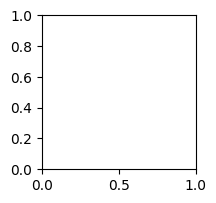

In [ ]:
# 可视化地理数据
plot_gdf(gdf)
plt.show()

In [ ]:
concept_d= pickle.load(open('init_plan_grid3_concept.pickle', 'rb'))

In [ ]:
concept_d

{'concept': [{'distance': 200,
   'geometry': <shapely.geometry.point.Point at 0x7f6b04532ee0>,
   'land_use': [5, 6],
   'type': 'center'},
  {'distance': 50,
   'geometry': <shapely.geometry.linestring.LineString at 0x7f6bd6577670>,
   'land_use': [12],
   'type': 'axis'},
  {'distance': 50,
   'geometry': <shapely.geometry.linestring.LineString at 0x7f6b0418f430>,
   'land_use': [7, 8],
   'type': 'axis'}],
 'gdf':     id  type  existence                                           geometry
 0    1    13       True                                POINT (0.000 0.000)
 1    2    13       True                             POINT (1000.000 0.000)
 2    3    13       True                          POINT (1000.000 1000.000)
 3    4    13       True                             POINT (0.000 1000.000)
 4    9     1       True  POLYGON ((0.000 0.000, 1000.000 0.000, 1000.00...
 5   12    13       True                          POINT (1000.000 2000.000)
 6   13    13       True                       

In [ ]:
gdf= concept_d['gdf']

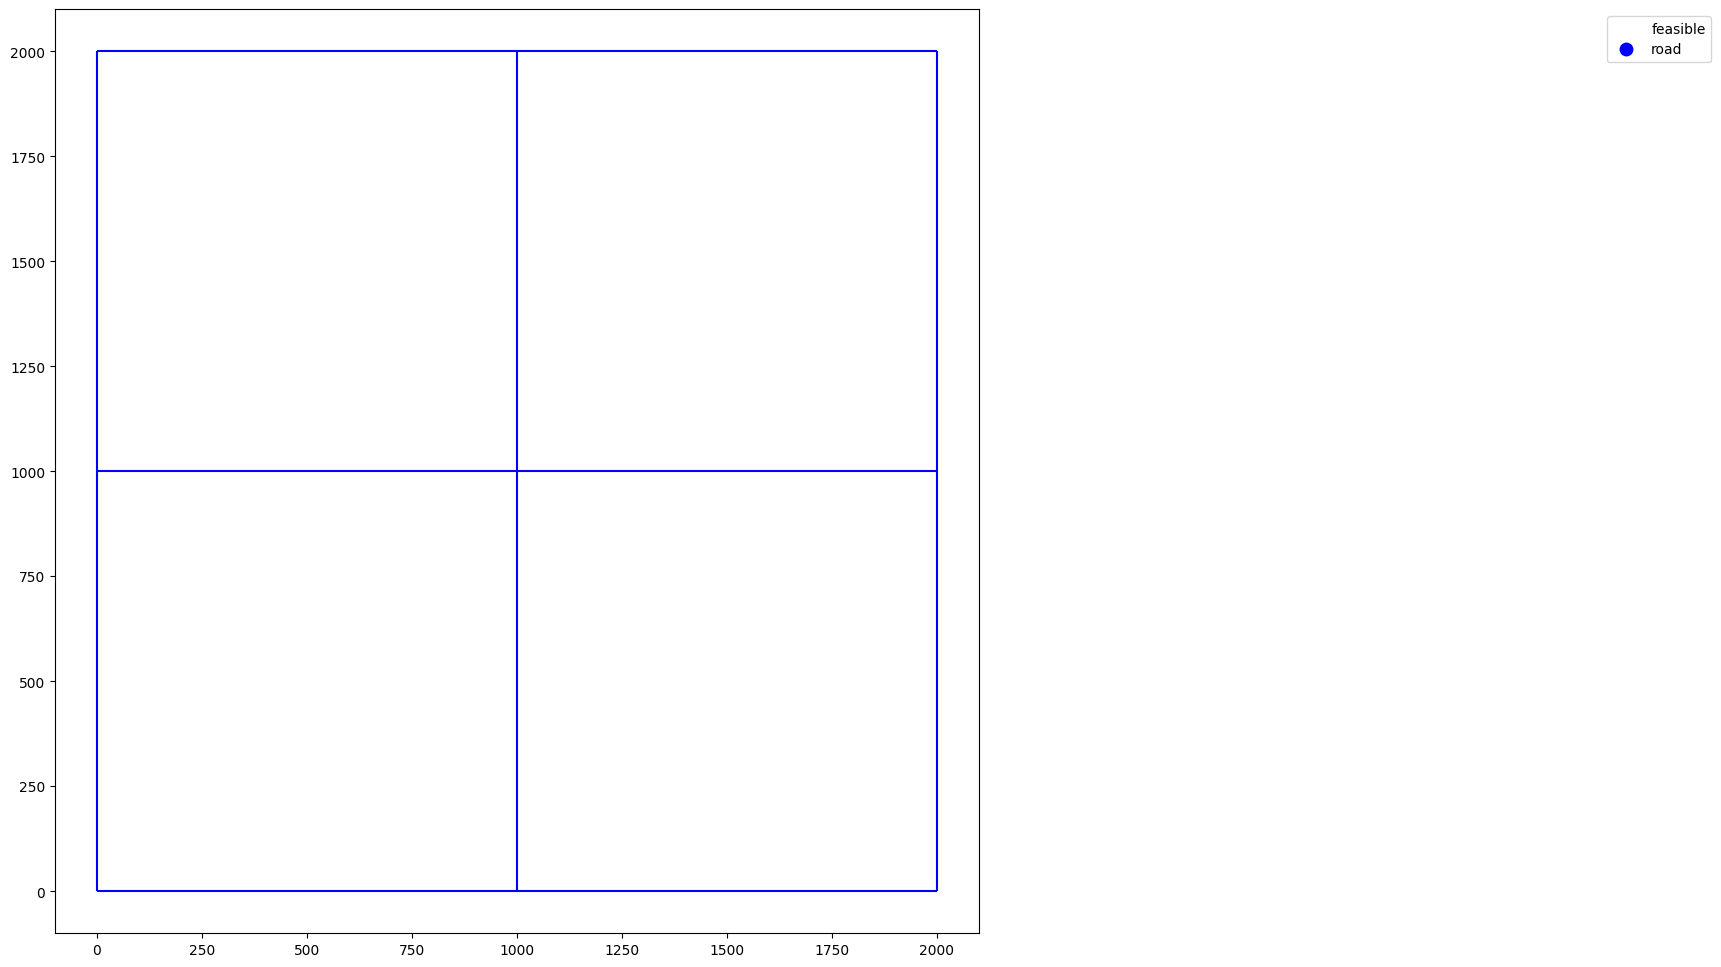

In [ ]:
env.load_plan(gdf)
env.visualize()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Load your GeoDataFrame
gdf = gpd.read_file("output.geojson")  # Replace with your file

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_gdf_with_rgb(gdf, rgb_colors=None, figsize=(10, 10), alpha=0.7):
    """
    Plot GeoDataFrame with RGB colors
    
    Args:
        gdf: GeoDataFrame to plot
        rgb_colors: Dict of type_id: (r,g,b) where r,g,b are 0-255
        figsize: Tuple for figure size
        alpha: Float for transparency
    """
    if rgb_colors is None:
        # Default colors as example
        rgb_colors = {
            1: (255, 99, 71),   # Tomato red
            2: (70, 130, 180),  # Steel blue
            13: (34, 139, 34)   # Forest green
        }
    
    # Convert RGB (0-255) to matplotlib format (0-1)
    color_map = {
        k: (r/255, g/255, b/255) 
        for k, (r,g,b) in rgb_colors.items()
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each type with its color
    for type_id, color in color_map.items():
        mask = gdf['type'] == type_id
        if mask.any():
            gdf[mask].plot(
                ax=ax,
                color=color,
                alpha=alpha
            )
    
    # Adjust plot
    plt.axis('equal')
    plt.grid(True)
    plt.show()
    
    return fig, ax

In [ ]:
plot_gdf_with_rgb(gdf)

NameError: name 'plot_gdf_with_rgb' is not defined

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

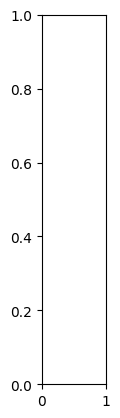

In [ ]:
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(3,2))
    
    gdf[gdf.geometry.type == 'Polygon'].plot(ax=ax, color='(172/255, 255/255, 207/255, 1.0)', edgecolor='black')

    gdf[gdf.geometry.type == 'LineString'].plot(ax=ax, color='red')
    gdf.plot(ax=ax, linewidth=1, markersize=2 , **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_aspect('equal')
    if filename is not None:
        plt.savefig(filename)
    plt.show()

# Assume you have a column 'value' in your GeoDataFrame that determines color
# Replace 'value' with the actual column name

# Create an array of RGBA values.  These are normalized to 0-1.
# Example:  Assume 'value' ranges from 0 to 100.
rgba_colors = np.zeros((len(gdf), 4))
rgba_colors[:, 0] = 1  # Red component (0-1)
rgba_colors[:, 1] = 1 / 100  # Green component (1-0)
rgba_colors[:, 2] = 0.5  # Blue component (constant)
rgba_colors[:, 3] = 0.8 # Alpha component (transparency)


# Create a custom colormap from your RGBA values.  ListedColormap is good for discrete colors
# For continuous data, you may want to use LinearSegmentedColormap (more complex setup)
cmap = mcolors.ListedColormap(rgba_colors)

# Plot the GeoDataFrame using the custom colormap
gdf.plot(column='geometry', cmap=cmap, linewidth=0.8, edgecolor='0.8', legend=True)
plt.show()


#Alternative for continuous data using LinearSegmentedColormap (requires more adjustments based on your data range)

#Define your RGBA colors as a list of tuples  (example: 3 colors)
colors = [(1,0,0,0.8), (0,1,0,0.8), (0,0,1,0.8)]
# create a linear segmented colormap
cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", colors)
#Normalize your data.  vmin and vmax are crucial for mapping your data to the colors correctly.
norm = mcolors.Normalize(vmin=gdf['value'].min(), vmax=gdf['value'].max())
#plot with normalization and custom cmap
gdf.plot(column='value', cmap=cmap, norm=norm, linewidth=0.8, edgecolor='0.8', legend=True)
plt.show()